# **zkCredit**

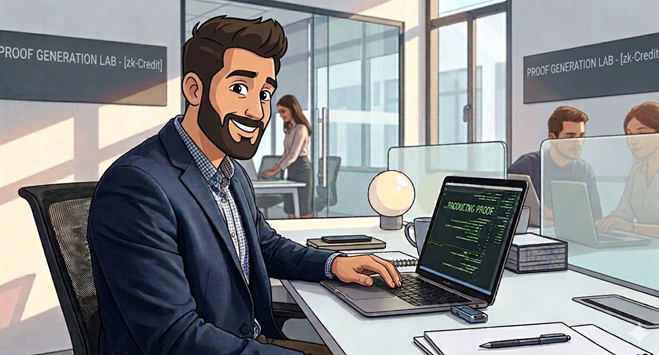

# **py_ecc is a Python implementation of elliptic curve cryptography, including support for various curves like BN128, secp256k1, and bls12_381.**

In [ ]:
!pip install py-ecc
!pip install galois

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 617.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 12.6 MB/s eta 0:00:00


**Circuit Definition**

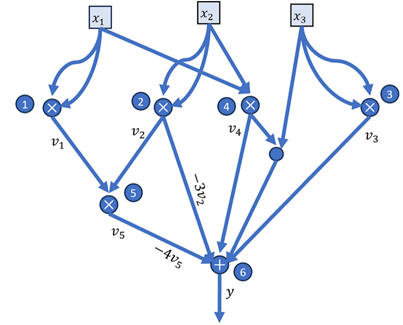

In [ ]:
import galois
import numpy as np

# p = 71
p = 21888242871839275222246405745257275088548364400416034343698204186575808495617
FP = galois.GF(p)

x1 = FP(2)
x2 = FP(7)
x3 = FP(4)

v1 = x1 * x1
v2 = x2 * x2
v3 = x3 * x3
v4 = x1 * x2
v5 = v1 * v2;
y = -3*v2 + v3 + v4 - 4*v5 -v4*x3;

# **Converting Constraint Systems into Matrises**

In [ ]:
W = FP([1, y, x1, x2, x3, v1, v2, v3, v4, v5])

print("W =", W)

xL = FP([[0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
         [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, FP(p - 1), 0]])

xR = FP([[0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

xO = FP([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
         [0, 1, 0, 0, 0, 0, 3, FP(p - 1), FP(p - 1), 4]])

W = [                                                                            1
 21888242871839275222246405745257275088548364400416034343698204186575808494660
                                                                             2
                                                                             7
                                                                             4
                                                                             4
                                                                            49
                                                                            16
                                                                            14
                                                                           196]


# **Naive Protocol**

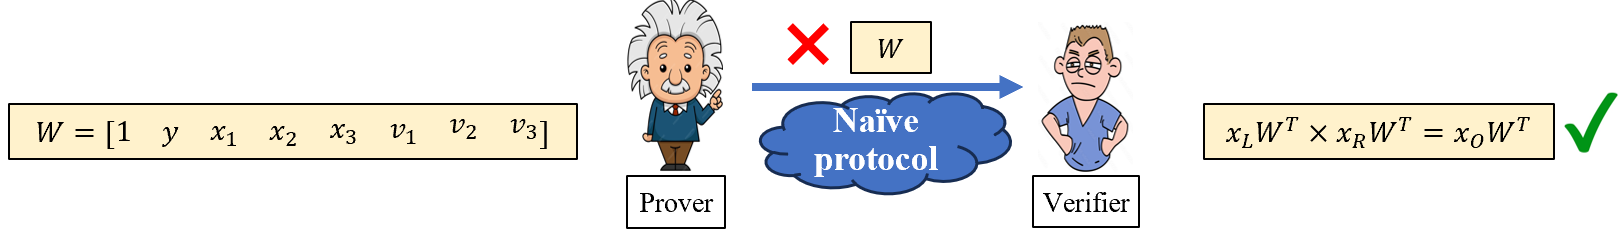

In [ ]:
W = FP([1, y, x1, x2, x3, v1, v2, v3, v4, v5])
print("W =", W)

xLWT = np.dot(xL, W)
xRWT = np.dot(xR, W)
xOWT = np.dot(xO, W)

print("xL.WT =", xLWT)
print("xR.WT =", xRWT)

xLWTxRWT = np.multiply(xLWT, xRWT)

print("xL.WT * xR.WT =", xLWTxRWT)

print("xO.WT =", xOWT)

assert np.all(xLWTxRWT == xOWT)
print("\nxLWT * xRWT = xOWT! So, verification is passed!")

W = [                                                                            1
 21888242871839275222246405745257275088548364400416034343698204186575808494660
                                                                             2
                                                                             7
                                                                             4
                                                                             4
                                                                            49
                                                                            16
                                                                            14
                                                                           196]
xL.WT = [                                                                            2
                                                                             7
                                       

# **QAP (convering matrises into polynomials)**

In [ ]:
mtxs = [xL, xR, xO]
poly_m = []

for m in mtxs:
    poly_list = []
    for i in range(0, m.shape[1]):
        points_x = FP(np.zeros(m.shape[0], dtype=int))
        points_y = FP(np.zeros(m.shape[0], dtype=int))
        for j in range(0, m.shape[0]):
            points_x[j] = FP(j+1)
            points_y[j] = m[j][i]

        poly = galois.lagrange_poly(points_x, points_y)
        coef = poly.coefficients()[::-1]
        if len(coef) < m.shape[0]:
            coef = np.append(coef, np.zeros(m.shape[0] - len(coef), dtype=int))
        poly_list.append(coef)

    poly_m.append(FP(poly_list))

L_polys = poly_m[0]
R_polys = poly_m[1]
O_polys = poly_m[2]

print(f'''L_polys
{L_polys}
''')

print(f'''R_polys
{R_polys}
''')

print(f'''O_polys
{O_polys}
''')

Lx = galois.Poly((W @ L_polys)[::-1])
Rx = galois.Poly((W @ R_polys)[::-1])
Ox = galois.Poly((W @ O_polys)[::-1])

print("L(x) = ", Lx)
print("R(x) = ", Rx)
print("O(x) = ", Ox)

L_polys
[[                                                                            0
                                                                              0
                                                                              0
                                                                              0
                                                                              0
                                                                              0]
 [                                                                            0
                                                                              0
                                                                              0
                                                                              0
                                                                              0
                                                                              0]
 [2188824287183927522224640574

# **Computing Polynomials T(x) and H(x)**

In [ ]:
Tx = galois.Poly([1, p-1], field=FP)
for i in range(2, xL.shape[0] + 1):
    Tx *= galois.Poly([1, p-i], field=FP)

print("\nT(x) = ", Tx)
for i in range(1, xL.shape[0] + 2):
    #print(f"T({i}) = ", Tx(i))
    if i == xL.shape[0]:
        print("-"*10)

Hx = (Lx * Rx - Ox) // Tx
rem = (Lx * Rx - Ox) % Tx

print("H(x) = ", Hx)
print("rem(x) = ", rem)

assert rem == 0


T(x) =  x^6 + 21888242871839275222246405745257275088548364400416034343698204186575808495596x^5 + 175x^4 + 21888242871839275222246405745257275088548364400416034343698204186575808494882x^3 + 1624x^2 + 21888242871839275222246405745257275088548364400416034343698204186575808493853x + 720
----------
H(x) =  15330890111484092353581753357407283093270750232124730721565283849014139200472x^4 + 18910529831149473822219967630329566623377097326776103004857594325360391214857x^3 + 10360434959337256938529965386088443541912892482863589589350483314979216021263x^2 + 19457735902945455702776127773960998500590806436786503863450049430024786427249x + 14683362926525513794923630520776755371901194451945756372230878641827938199141
rem(x) =  0


# **Test version 1**

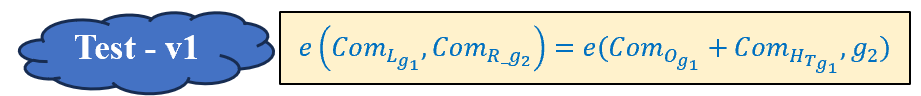

# **Test 1 - Generating Public Parameters (SRS) by trusted authority**

In [ ]:
print("Setup phase")
print("-"*10)

tau = FP(20)
print(f"The trusted authority chooses that toxic waste: τ = {tau}")

Lx_tau = Lx(tau)
Rx_tau = Rx(tau)
Ox_tau = Ox(tau)

Tx_tau = Tx(tau)
# print(f"\nT(τ) = {Tx_tau}")

Hx_tau = Hx(tau)

HTx_tau = Hx_tau*Tx_tau

assert Lx_tau * Rx_tau == Ox_tau + HTx_tau, f"{Lx_tau} * {Rx_tau} - {Ox_tau} != {HTx_tau}"
print("This equation is correct: Lx(τ)*Rx(τ) = Ox(τ) + HTx(τ)")

from py_ecc.optimized_bn128 import multiply, G1, G2, add, pairing, neg, normalize

SRS_G1 = [multiply(G1, int(tau**i)) for i in range(0, Tx.degree)]                        # G1[τ^0], G1[τ^1], ..., G1[τ^d]
SRS_G2 = [multiply(G2, int(tau**i)) for i in range(0, Tx.degree)]                        # G2[τ^0], G2[τ^1], ..., G2[τ^d-1]
SRS_Ttau_G1 = [multiply(G1, int(tau**i * Tx_tau)) for i in range(0, Tx.degree - 1)]      # G1[τ^0 * T(τ)], G1[τ^1 * T(τ)], ..., G1[τ^d-1 * T(τ)]

print("SRS Generation:")
print("-"*10)
print(f"SRS_G1 = {[normalize(point) for point in SRS_G1]}")
print(f"\nSRS_G2 = {[normalize(point) for point in SRS_G2]}")
print(f"\nSRS_Ttau_G1 = {[normalize(point) for point in SRS_Ttau_G1]}")

Setup phase
----------
The trusted authority chooses that toxic waste: τ = 20
This equation is correct: Lx(τ)*Rx(τ) = Ox(τ) + HTx(τ)
SRS Generation:
----------
SRS_G1 = [(1, 2), (18947110137775984544896515092961257947872750783784269176923414004072777296602, 12292085037693291586083644966434670280746730626861846747147579999202931064992), (16262199471205794413544947826745938654132104752637586692048329713311590397011, 13296900385261935021718889695689394625708483652039722230815936262285054528714), (21603600070689675766438470661345954782419355034652174505468210225883925863279, 15787091953565760722773063158476721787069408761080596737736006929439659337677), (3791913980001525405070663195453841654293855276471519589821575313643995787424, 2219850731288481436925303713906758446890789653022769553096390029843417460412), (6779621809516151986945641406336169543842908834692441338288564144351856901573, 1474660080685150469507045477646463875368452658327288987469380125599003345221)]

SRS_G2 = [((1085704699902

# **Test 1 - Gerating Proof by Prover**

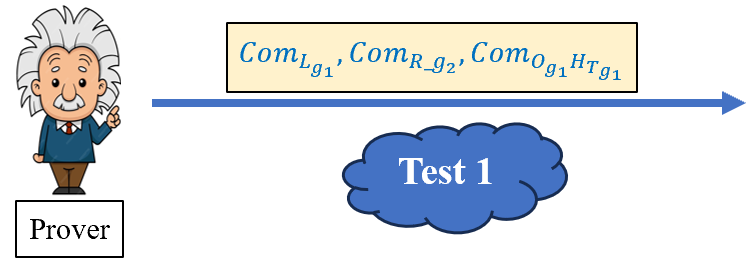

In [ ]:
def compute_commit(poly, trusted_points, verbose=False):
    coeff = poly.coefficients()[::-1]

    assert len(coeff) == len(trusted_points), "Polynomial degree mismatch!"

    if verbose:
        [print(normalize(point)) for point in trusted_points]

    terms = [multiply(point, int(coeff)) for point, coeff in zip(trusted_points, coeff)]
    evaluation = terms[0]
    for i in range(1, len(terms)):
        evaluation = add(evaluation, terms[i])

    if verbose:
        print("-"*10)
        print(normalize(evaluation))
    return evaluation

print("\nProof generation by the prover:")
print("-"*10)

Com_L_G1 = compute_commit(Lx, SRS_G1)         # G1[L0 * τ^0] + G1[L1 * τ^1] + ... + G1[Ld-1 * τ^d-1]
Com_R_G2 = compute_commit(Rx, SRS_G2)         # G2[R0 * τ^0] + G2[R1 * τ^1] + ... + G2[Rd-1 * τ^d-1]
Com_O_G1 = compute_commit(Ox, SRS_G1)         # G1[O0 * τ^0] + G1[O1 * τ^1] + ... + G1[Od-1 * τ^d-1]
Com_H_TG1 = compute_commit(Hx, SRS_Ttau_G1)   # G1[h0 * τ^0 * T(τ)] + G1[h1 * τ^1 * T(τ)] + ... + G1[hd-2 * τ^d-2 * T(τ)]
Com_O_G1_H_TG1 = add(Com_O_G1, Com_H_TG1)

print(f"Com_L_G1 = {normalize(Com_L_G1)}")
print(f"Com_R_G2 = {normalize(Com_R_G2)}")
print(f"Com_O_G1 = {normalize(Com_O_G1)}")
print(f"Com_H_TG1 = {normalize(Com_H_TG1)}")
print(f"Com_O_G1_H_TG1 = {normalize(Com_O_G1_H_TG1)}")


Proof generation by the prover:
----------
Com_L_G1 = (779145915074139571602978606749754293145426436361796191175872619063318662045, 12134787638081272075373094060755692367573238440381235745990701692275533404589)
Com_R_G2 = ((2528500125020256724313913255937180856125929313687927251330738430589585554587, 15957063991508639426675718192050352547654780434139038958721341853458052056440), (9307414665235491907225387437579833369725478945643995774090055981070400650342, 18159519495390228375350838020777393932562244164065691352645195258717822722195))
Com_O_G1 = (2830689237110260460000889035093308144165736412771979077286142010257410071744, 11219715829872634914561135363979905431175891558405823647864423188704414943932)
Com_H_TG1 = (483278042138942747158750408879911353340741952884210101367439041446372119874, 10802780872058647422243811949201264486575013259961114221932124887541691987749)
Com_O_G1_H_TG1 = (18130907426914807407691078674714792801532583935697928369065933213628702869081, 97647780013717263129342

# **Test 1 - Verifying Proof by Verifier**

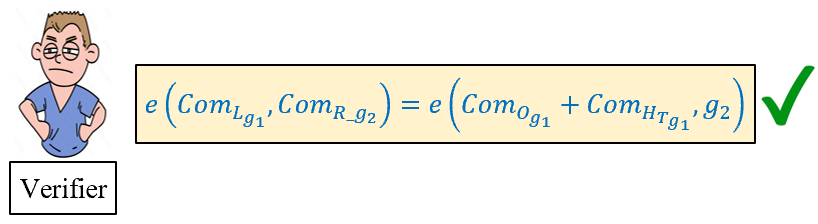

In [ ]:
print("\nProof verification by the verifier:")
print("-"*10)

print(f"pairing(Com_R_G2,Com_L_G1) = {pairing(Com_R_G2,Com_L_G1)}")
print(f"pairing(G2,add(Com_O_G1, Com_H_TG1)) = {pairing(G2,Com_O_G1_H_TG1)}")

assert pairing(Com_R_G2,Com_L_G1) == pairing(G2,Com_O_G1_H_TG1)    # e(Com_L_G1, Com_R_G2) == e(Com_OHT_G1, G2[1])
print("Pairing check passed!")


Proof verification by the verifier:
----------
pairing(Com_R_G2,Com_L_G1) = (12058719276827581283389290703090984326536350979236895343789026659700402932434, 8587741751803757894375987012538355724465951036179071550813773390210413448382, 20780254192563221630726610307967170168103554418779709047972711885922493032917, 9303659348381291333014742884985254909263571846402706021964920911184127291226, 21182665149230171603157190786925600478478882217778337154028166206249578546307, 20477650094696188902271813758049412592643034685362816182006748544459195356901, 19046205633519952835779789549086799400629574621534053147629264383387363813384, 11005866386452648646352959942136353300419691583345720174416533636307809252928, 12450820632945723673644941597557704154404751943273358406307861326427956174188, 15717582185477022324797228911493340946616010303113881780876679685999836731023, 8599814460154017044849001910803399893517603478804148374098007727514253896931, 77043901625257786549281416963997697117771414427598572974

# **Test 2 - Checking**

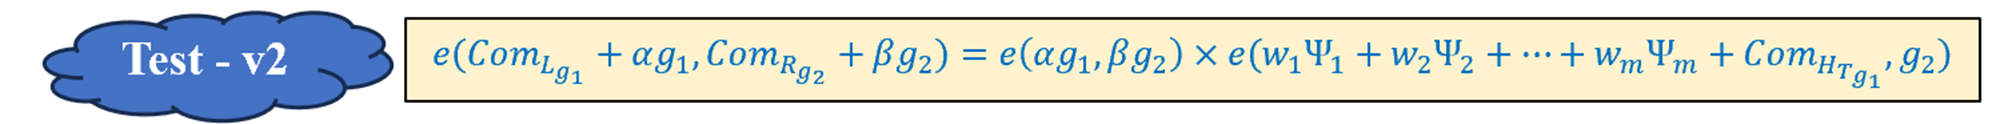

# **Test 2 - Choosing α, β by trusted authority**

In [ ]:
print("Setup phase")
print("-"*10)
print("Toxic waste:")
tau = FP(20)
alpha = FP(2)
beta = FP(3)

print(f"τ = {tau}")
print(f"α = {alpha}")
print(f"β = {beta}")

Setup phase
----------
Toxic waste:
τ = 20
α = 2
β = 3


# **Test 2 - Computing psi by trusted authority**

In [ ]:
def evaluate_poly_list(poly_list, x):
    results = []
    for poly in poly_list:
        results.append(poly(x))
    return results

def print_evaluation(name, results):
    print(f'\n{name} polynomial evaluations:')
    for i in range(0, len(results)):
        print(f'{name}_{i} = {results[i]}')

def to_poly(mtx):
    poly_list = []
    for i in range(0, mtx.shape[0]):
        poly_list.append( galois.Poly(mtx[i][::-1]) )
    return poly_list

def print_poly(name, poly_list):
    print(f'\n{name} polynomials:')
    for i in range(0, len(poly_list)):
        print(f'{name}_{i} = {poly_list[i]}')

beta_L = beta * L_polys
alpha_R = alpha * R_polys

print("βL\n", beta_L)
print("αR\n", alpha_R)
print("O\n", O_polys)

psi = beta_L + alpha_R + O_polys
print("psi = βL + αR + O\n", psi)

psi_p = to_poly(psi)
print_poly("psi", psi_p)

print("psi evaluations:")
psi_eval = evaluate_poly_list(psi_p, tau)
print([int(k) for k in psi_eval])




βL
 [[                                                                            0
                                                                              0
                                                                              0
                                                                              0
                                                                              0
                                                                              0]
 [                                                                            0
                                                                              0
                                                                              0
                                                                              0
                                                                              0
                                                                              0]
 [21888242871839275222246405745257

# **Test 2 - Generating SRS**

In [ ]:
from py_ecc.optimized_bn128 import multiply, G1, G2, add, pairing, neg, normalize, eq

alphaG1 = multiply(G1, int(alpha))         # G1[α]
betaG2 = multiply(G2, int(beta))    # G2[α]
psi_G1 = [multiply(G1, int(k)) for k in psi_eval]       # G1[βU0(τ) + αV0(τ) + W0(τ)], G1[βU1(τ) + αV1(τ) + W1(τ)], ..., G1[βUd(τ) + αVd(τ) + Wd(τ)]

print("Trusted setup:")
print("-"*10)
print(f"\n[α]G1 = {normalize(alphaG1)}")
print(f"[β]G2 = {normalize(betaG2)}")
print(f"psi_G1 = {[normalize(point) for point in psi_G1]}")

Trusted setup:
----------

[α]G1 = (1368015179489954701390400359078579693043519447331113978918064868415326638035, 9918110051302171585080402603319702774565515993150576347155970296011118125764)
[β]G2 = ((2725019753478801796453339367788033689375851816420509565303521482350756874229, 7273165102799931111715871471550377909735733521218303035754523677688038059653), (2512659008974376214222774206987427162027254181373325676825515531566330959255, 957874124722006818841961785324909313781880061366718538693995380805373202866))
psi_G1 = [(0, 0), (9593804285824865463862622830146670686994293452661354516716859801367441463036, 7464410802786249411703557714657240083637342517398030310909682142718422834169), (6457971683548083429779386736024761861931138352829397962431984824078950697108, 167275556522480392755282468489626964451116836821463996096637596640679272901), (11876070838681804245852881475823368594754994920356853667574582752251828735529, 10726319625694373315015812844219823831934131183578780899625029073315829

# **Test 2 - Proof genration by Prover**

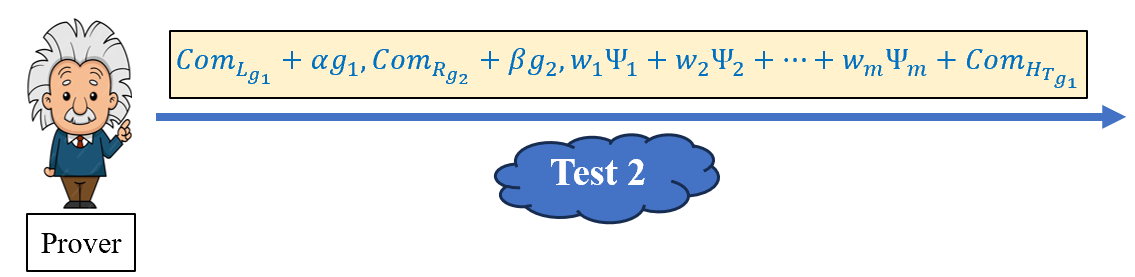

In [ ]:
print("\nProof generation:")
print("-"*10)

Com_Lalpha_G1 = add(Com_L_G1, alphaG1)        # G1[A] = G1[A] + G1[α]
Com_Rbeta_G2 = add(Com_R_G2, betaG2)    # G2[B] = G2[B] + G2[β]
# assert len(W) == len(psi_G1), "Polynomial degree mismatch!"    # w0 * G1[k0] + w1 * G1[k1] + ... + wd-1 * G1[kd-1]
psi_G1 = [multiply(G1, int(k)) for k in psi_eval]
psi_G1_terms = [multiply(point, int(scaler)) for point, scaler in zip(psi_G1, W)]
sum_psi_G1 = psi_G1_terms[0]
for i in range(1, len(psi_G1_terms)):
    sum_psi_G1 = add(sum_psi_G1, psi_G1_terms[i])
Com_sum_psi_H_TG1 = add(Com_H_TG1, sum_psi_G1)

print(f"Com_Lalpha_G1 = {normalize(Com_Lalpha_G1)}")
print(f"Com_Rbeta_G2 = {normalize(Com_Rbeta_G2)}")
print(f"Com_sum_psi + Com_H_TG1 = {normalize(Com_sum_psi_H_TG1)}")
#print(f"psi_G1 = {normalize(psi_G1)}")


Proof generation:
----------
Com_Lalpha_G1 = (6723796196779911458409689644983887773475931039053322380840392382403213924237, 11816234300097214807126574552610684524320476467828977216224456145077396952816)
Com_Rbeta_G2 = ((18375331568465202566346745597445209206442584265035096442331651096103982531564, 21008924132182405309168326651697876018858097100653607445650372614560773045135), (13058020351911908736393425713185623501690645841062520859605845684919861881417, 11667336354331518175818809211623223262832730810542104550658366313715703038856))
Com_sum_psi + Com_H_TG1 = (12663742099780550840566208318309545951265310505696031075940649775639471423280, 7487402245246494546815562375448122444579868127389788328221762527913852786336)


# **Test 2 - Proof verification by Verifier**

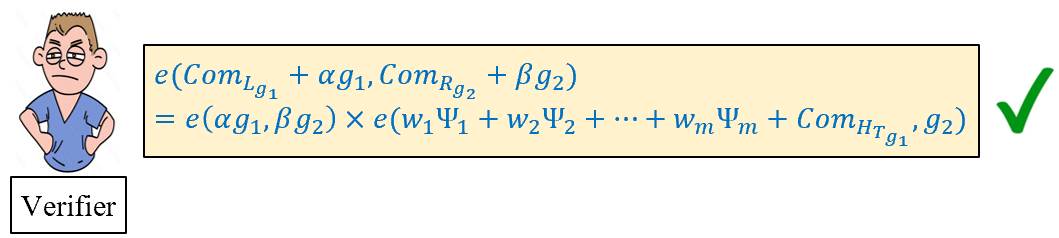

In [ ]:
print("\nProof verification by the verifier:")
print("-"*10)

print(f"pairing(Com_Rbeta_G2,Com_Lalpha_G1) = {pairing(Com_Rbeta_G2,Com_Lalpha_G1)}")
print(f"pairing(betaG2, alphaG1) = {pairing(betaG2, alphaG1)}")
print(f"pairing(G2, Com_sum_psi_H_TG1) = {pairing(G2, Com_sum_psi_H_TG1)}")
print(f"pairing(betaG2, alphaG1) * pairing(G2, Com_sum_psi_H_TG1) = {pairing(betaG2, alphaG1) * pairing(G2, Com_sum_psi_H_TG1)}")

assert pairing(Com_Rbeta_G2,Com_Lalpha_G1) == pairing(betaG2, alphaG1) * pairing(G2, Com_sum_psi_H_TG1)
print("\nPairing check passed!")


Proof verification by the verifier:
----------
pairing(Com_Rbeta_G2,Com_Lalpha_G1) = (16403264132976422610285103883305645054376260876916255965877647347945908796669, 7397309472688045675124990869586029701323372810823028412988862182019151565100, 18705449065164007279369796857905059186920898043499560561093429836117842800660, 17646965249818085612700979744562207624556233857429702595147442711766340933100, 14435518807737546217462392802721619645918160413833987127492758186629839176232, 4816038329199479005867790665697064105488679712149296863083203890376215997145, 11745043107910678827515295611697677203359884027847123528308751215533021644274, 6674058517144546661519175117636857889858725909045457985866997262416606588038, 5375887971039313337218824834977694470734004896584870823876714119278388262634, 16346413557801982876757544673748423563678435426581155726133963054541447480225, 9579615097046619437043564135739503429240324359646680397957692018775934757889, 1979232940971137378953183145028838675163404969409

# **Test 3 - Checking**

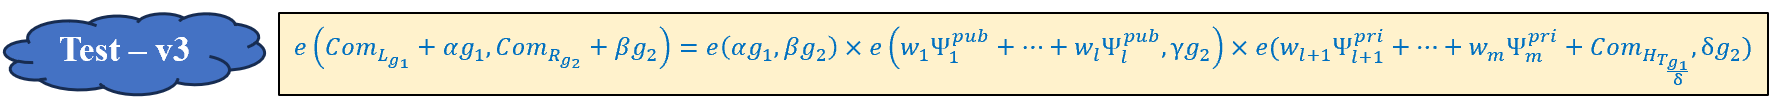

# **Test 3 -Choosing gamma, delta (γ, δ) by trusted authority**

In [ ]:
print("Setup phase")
print("-"*10)
print("Toxic waste:")
tau = FP(20)
alpha = FP(2)
beta = FP(3)
gamma = FP(4)
delta = FP(5)

print(f"τ = {tau}")
print(f"α = {alpha}")
print(f"β = {beta}")
print(f"γ = {gamma}")
print(f"δ = {delta}")

Setup phase
----------
Toxic waste:
τ = 20
α = 2
β = 3
γ = 4
δ = 5


# **Test 3 -Generating SRS by trusted authority**

In [ ]:
print("Trusted setup:")
print("-"*10)

gammaG2 = multiply(G2, int(gamma))
print(f"\ngammaG2 = {normalize(gammaG2)}")

deltaG2 = multiply(G2, int(delta))
print(f"deltaG2 = {normalize(deltaG2)}")

powers_tauTtau_div_delta = [(tau**i * Tx_tau) / delta for i in range(0, Tx.degree - 1)]
SRS_Ttau_div_delta_G1 = [multiply(G1, int(pTd)) for pTd in powers_tauTtau_div_delta]
print(f"(τT(τ)/δ)*G1 = {[normalize(point) for point in SRS_Ttau_div_delta_G1]}")
assert len(SRS_Ttau_div_delta_G1) == len(Hx.coefficients()), f"SRS_Ttau_div_delta_G1 length mismatch! {len(SRS_Ttau_div_delta_G1)} != {len(H.coefficients())}"

W_pub = W[:2]
W_pri = W[2:]

psi_pub_ints= [int(psi_eval[k]) for k in range(2)];
psi_pri_ints=[int(psi_eval[k]) for k in range(2,len(psi_eval))]

psi_pub = [FP(k)/gamma for k in psi_pub_ints]
psi_pri = [FP(k)/delta for k in psi_pri_ints]

psi_pub_G1 = [multiply(G1, int(k)) for k in psi_pub]
psi_pri_G1 = [multiply(G1, int(k)) for k in psi_pri]

print(f"[psi/γ]G1 = {[normalize(point) for point in psi_pub_G1]}")
print(f"[psi/δ]G1 = {[normalize(point) for point in psi_pri_G1]}")

Trusted setup:
----------

gammaG2 = ((18936818173480011669507163011118288089468827259971823710084038754632518263340, 18556147586753789634670778212244811446448229326945855846642767021074501673839), (18825831177813899069786213865729385895767511805925522466244528695074736584695, 13775476761357503446238925910346030822904460488609979964814810757616608848118))
deltaG2 = ((20954117799226682825035885491234530437475518021362091509513177301640194298072, 4540444681147253467785307942530223364530218361853237193970751657229138047649), (21508930868448350162258892668132814424284302804699005394342512102884055673846, 11631839690097995216017572651900167465857396346217730511548857041925508482915))
(τT(τ)/δ)*G1 = [(21412189381085960759243799641057498158975024404668925481632529537822658071670, 21695943041257517350405364634360174609628306046920531160062076851206244233517), (9488455588199637107805441854366172138373032619420355720371500844537207415944, 174391565671766165360744136742022226034287470235200158424

# **Test 3 -Proof Generation by Prover**

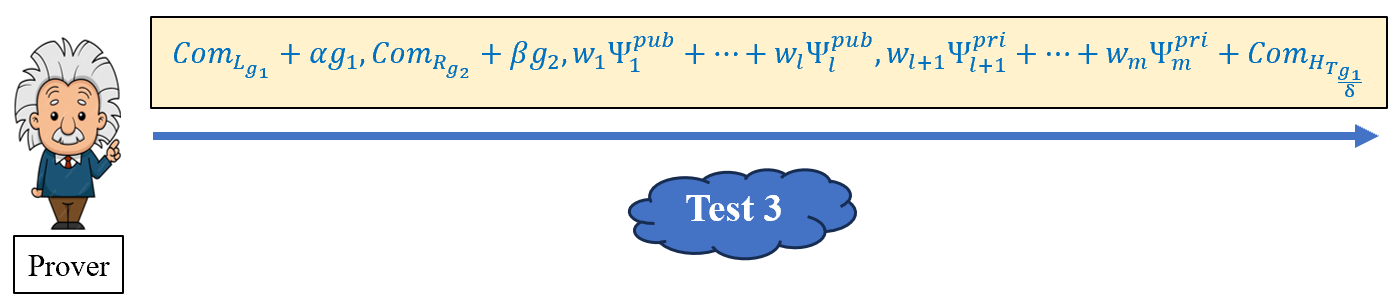

In [ ]:
psi_pubW_G1_terms = [multiply(point, int(scaler)) for point, scaler in zip(psi_pub_G1, W_pub)]
psi_pubW_G1 = psi_pubW_G1_terms[0]
for i in range(1, len(psi_pubW_G1_terms)):
    psi_pubW_G1 = add(psi_pubW_G1, psi_pubW_G1_terms[i])
print(f"[psi_pub/γ*w]G1 = {normalize(psi_pubW_G1)}")

psi_priW_G1_terms = [multiply(point, int(scaler)) for point, scaler in zip(psi_pri_G1, W_pri)]
psi_priW_G1 = psi_priW_G1_terms[0]
for i in range(1, len(psi_priW_G1_terms)):
    psi_priW_G1 = add(psi_priW_G1, psi_priW_G1_terms[i])
print(f"[psi_pri/δ*w]G1 = {normalize(psi_priW_G1)}")


Com_H_Tdelta_G1 = compute_commit(Hx, SRS_Ttau_div_delta_G1)
print(f"\n[τT(τ)/δ]G1 = {normalize(Com_H_Tdelta_G1)}")

[psi_pub/γ*w]G1 = (13633155080432457891352833429200078666089836773173407505221174498237575914235, 21748481848325875740942185935463118151122266705464510307643667701667039079628)
[psi_pri/δ*w]G1 = (16442434163337919978369778072274409528622950934132292839271263675738998831509, 4941652099606113911396700578986370032592997254679658193915262302801261118717)

[τT(τ)/δ]G1 = (13332747917183738250651097986066307323619012881855345354377325059302013289790, 9859012115803733127424824789471027488515220783523845582601339957589716981322)


# **Test 3 -Proof Verification by Verifier**

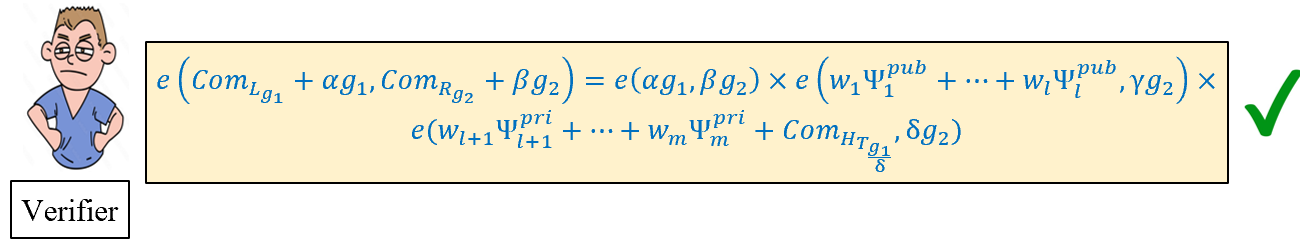

In [ ]:
print("\nProof verification by the verifier:")
print("-"*10)

print(f"pairing(Com_Rbeta_G2,Com_Lalpha_G1) = {pairing(Com_Rbeta_G2,Com_Lalpha_G1)}")
print(f"\npairing(betaG2, alphaG1) = {pairing(betaG2, alphaG1)}")
print(f"pairing(gammaG2, psi_pubW_G1) = {pairing(gammaG2, psi_pubW_G1)}")
print(f"pairing(deltaG2,add(psi_priW_G1, Com_H_Tdelta_G1)) = {pairing(deltaG2,add(psi_priW_G1, Com_H_Tdelta_G1))}")
print(f"pairing(betaG2, alphaG1) * pairing(G2, Com_sum_psi_H_TG1) = {pairing(betaG2, alphaG1) * pairing(gammaG2, psi_pubW_G1) * pairing(deltaG2,add(psi_priW_G1, Com_H_Tdelta_G1))}")

assert pairing(Com_Rbeta_G2,Com_Lalpha_G1) == pairing(betaG2, alphaG1) * pairing(gammaG2, psi_pubW_G1) * pairing(deltaG2,add(psi_priW_G1, Com_H_Tdelta_G1))
print("\nPairing check passed!")


Proof verification by the verifier:
----------
pairing(Com_Rbeta_G2,Com_Lalpha_G1) = (16403264132976422610285103883305645054376260876916255965877647347945908796669, 7397309472688045675124990869586029701323372810823028412988862182019151565100, 18705449065164007279369796857905059186920898043499560561093429836117842800660, 17646965249818085612700979744562207624556233857429702595147442711766340933100, 14435518807737546217462392802721619645918160413833987127492758186629839176232, 4816038329199479005867790665697064105488679712149296863083203890376215997145, 11745043107910678827515295611697677203359884027847123528308751215533021644274, 6674058517144546661519175117636857889858725909045457985866997262416606588038, 5375887971039313337218824834977694470734004896584870823876714119278388262634, 16346413557801982876757544673748423563678435426581155726133963054541447480225, 9579615097046619437043564135739503429240324359646680397957692018775934757889, 1979232940971137378953183145028838675163404969409

# **Test 4 - Checking**

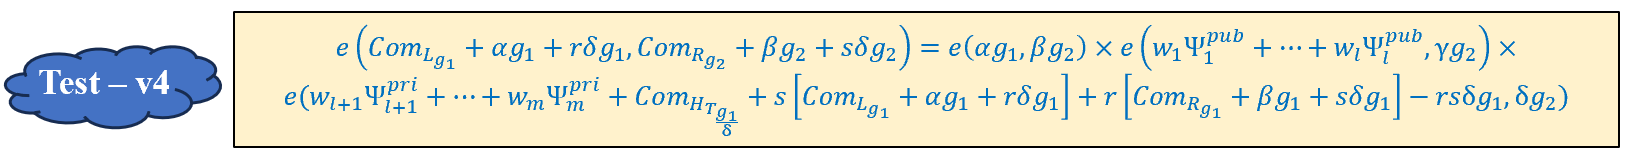

# **Test 4 - Updating SSR values by trusted authority**

In [ ]:
print("Additional Trusted setup:")
print("-"*10)

betaG1 = multiply(G1, int(beta))
deltaG1 = multiply(G1, int(delta))

print(f"[γ]G1 = {normalize(betaG1)}")
print(f"[beta]G1 = {normalize(deltaG1)}")


Additional Trusted setup:
----------
[γ]G1 = (3353031288059533942658390886683067124040920775575537747144343083137631628272, 19321533766552368860946552437480515441416830039777911637913418824951667761761)
[beta]G1 = (10744596414106452074759370245733544594153395043370666422502510773307029471145, 848677436511517736191562425154572367705380862894644942948681172815252343932)


# **Test 4 - Choosing random values r and s by Prover**

In [ ]:
print("Prover picks random r, s")
r = FP(12)
s = FP(13)

print(f"r = {r}")
print(f"s = {s}")

Prover picks random r, s
r = 12
s = 13


# **Test 4 -Proof Generation by Prover**

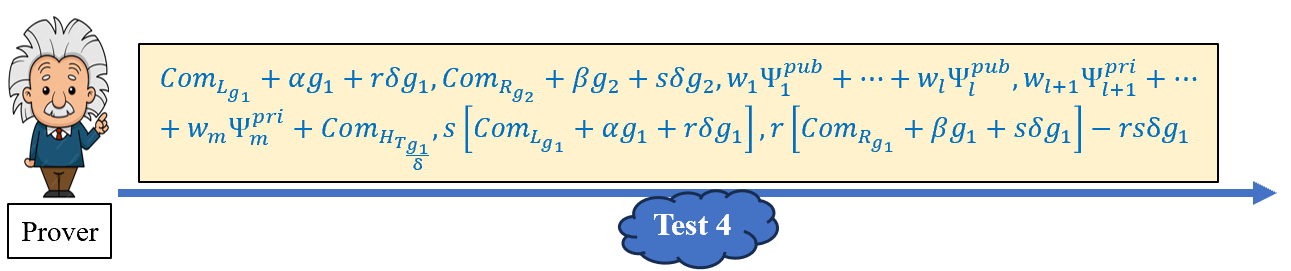

In [ ]:
r_deltaG1 = multiply(deltaG1, int(r))
s_deltaG1 = multiply(deltaG1, int(s))
s_deltaG2 = multiply(deltaG2, int(s))

Com_Lalpha_r_delta_G1 = add(Com_Lalpha_G1, r_deltaG1)
Com_Rbeta_s_delta_G2 = add(Com_Rbeta_G2, s_deltaG2)
print(f"Com_Lalpha_r_delta_G1 = {normalize(Com_Lalpha_r_delta_G1)}")
print(f"Com_Rbeta_s_delta_G2 = {normalize(Com_Lalpha_r_delta_G1)}")

Com_R_G1 = compute_commit(Rx, SRS_G1)
Com_Rbeta_G1 = add(Com_R_G1, betaG1)
Com_Rbeta_s_delta_G1 = add(Com_Rbeta_G1, s_deltaG1)
print(f"Com_Rbeta_s_delta_G1 = {normalize(Com_Rbeta_s_delta_G1)}")

sCom_Lalpha_r_delta_G1 = multiply(Com_Lalpha_r_delta_G1, int(s))
rCom_Rbeta_s_delta_G1 = multiply(Com_Rbeta_s_delta_G1, int(r))
rs_deltaG1 = multiply(deltaG1, int(-r*s))

Com_OHT_G1 = add(psi_priW_G1, Com_H_Tdelta_G1)      #replace Com_H_TG1 by Com_H_Tdelta_G1?
Com_OHT_G1 = add(Com_OHT_G1, sCom_Lalpha_r_delta_G1)
Com_OHT_G1 = add(Com_OHT_G1, rCom_Rbeta_s_delta_G1)
Com_OHT_G1 = add(Com_OHT_G1, rs_deltaG1)

print(f"[A]G1 = {normalize(Com_Lalpha_r_delta_G1)}")
print(f"[B]G2 = {normalize(Com_Rbeta_s_delta_G2)}")
print(f"[C]G1 = {normalize(Com_OHT_G1)}")

print(f"\npairing(Com_Rbeta_s_delta_G2, Com_Lalpha_r_delta_G1) = {pairing(betaG2, alphaG1)}")

Com_Lalpha_r_delta_G1 = (15449831961101541088665067435933884915761366157148486820250069318704068365426, 21488335903123485286445109704897365524769521813989335567410993512517313471430)
Com_Rbeta_s_delta_G2 = (15449831961101541088665067435933884915761366157148486820250069318704068365426, 21488335903123485286445109704897365524769521813989335567410993512517313471430)
Com_Rbeta_s_delta_G1 = (17207426683554703593600266110302490039900907866253807106068481151354259979104, 17349420393533926206516910422065028528811183641814064493341547405249552063661)
[A]G1 = (15449831961101541088665067435933884915761366157148486820250069318704068365426, 21488335903123485286445109704897365524769521813989335567410993512517313471430)
[B]G2 = ((13058368473570105012081778605725090762847780389979685315702591676113597548960, 15656371131523471772160755270648713299054878279902664963132188382406698635743), (5078104089308616981607286442358867222649182843626788772815662212280945184541, 88002231028961891181425187934513621574

# **Test 4 -Proof Verification by Verifier**

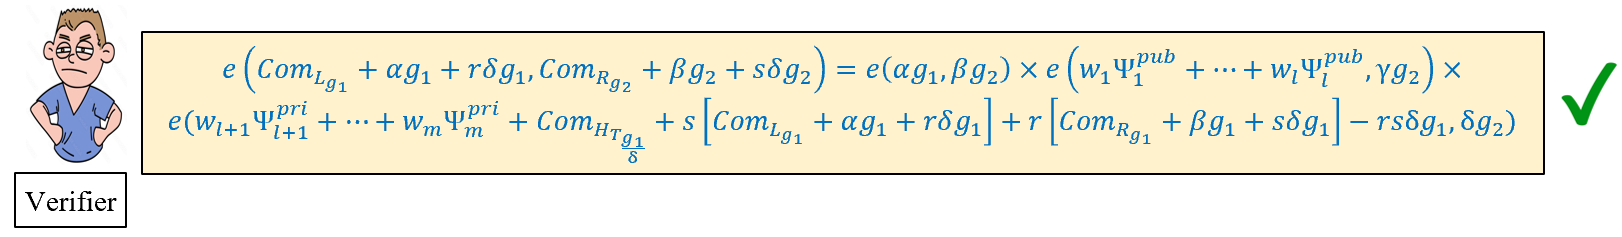

In [ ]:
assert pairing(Com_Rbeta_s_delta_G2, Com_Lalpha_r_delta_G1) == pairing(betaG2, alphaG1) * pairing(gammaG2, psi_pubW_G1) * pairing(deltaG2, Com_OHT_G1)
print("Pairing check passed!")

Pairing check passed!
